# Validation of my Bessetti-Erskine implementation against the 'PyPIC' solver for circular beam pipes

In [11]:
import sys
import os
import numpy as np
from scipy.constants import e, epsilon_0
import matplotlib.pyplot as plt

import PyPIC.FFT_OpenBoundary_SquareGrid as PIC_FFT

current_dir = os.getcwd()
pybe_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.insert(0, pybe_dir)

import bessetti_erskine

## Set up grid and chamber

In [12]:
grid_length = 100
aper_length = 100
Dh = aper_length/grid_length

pic_fft = PIC_FFT.FFT_OpenBoundary_SquareGrid(x_aper=aper_length, y_aper=aper_length, Dh=Dh)
x, y = np.meshgrid(pic_fft.yg, pic_fft.xg)

Start PIC init.:
FFT, Open Boundary
PyPIC Version 2.4.5
Using PyFFTW


## Solve for specific Gaussian charge distribution
Play with top 4 params!

In [13]:
sigma_x = 10
sigma_y = 15

A = 1./(2.*np.pi*sigma_x*sigma_y)  # Prefactor
s_squared = x**2/(sigma_x**2) + y**2/(sigma_y**2)  # elliptical radius squared
rho_matrix = A*np.exp(-s_squared/2)  # Gaussian in S

pic_fft.solve(rho=rho_matrix)

## Evaluate (probe) uniformly within the circle

In [14]:
probes_x = []
probes_y = []
for i in range(grid_length):
    for j in range(grid_length):
        x = (i-(grid_length/2))*2*aper_length/grid_length
        y = (j-(grid_length/2))*2*aper_length/grid_length
        probes_x.append(x)
        probes_y.append(y)
probes_x = np.array(probes_x)
probes_y = np.array(probes_y)


field_x_fft, field_y_fft = pic_fft.gather(probes_x, probes_y)

field_x_be, field_y_be = bessetti_erskine.gaussian_field(probes_x, probes_y, sigma_x, sigma_y)
field_x_be = 1/(4*np.pi*epsilon_0)*field_x_be
field_y_be = 1/(4*np.pi*epsilon_0)*field_y_be

## Gather probes back into an array

In [15]:
def gather_to_mesh(probes_x, probes_y, data, grid_length):
    arr = np.zeros((grid_length, grid_length))
    for n in range(len(probes_x)):
        i = int(round((grid_length/2) * (probes_x[n]/aper_length + 1)))
        j = int(round((grid_length/2) * (probes_y[n]/aper_length + 1)))
        arr[i,j]=data[n]
    return arr

field_x_fft_mesh = gather_to_mesh(probes_x, probes_y, field_x_fft, grid_length)
field_y_fft_mesh = gather_to_mesh(probes_x, probes_y, field_y_fft, grid_length)
field_x_be_mesh = gather_to_mesh(probes_x, probes_y, field_x_be, grid_length)
field_y_be_mesh = gather_to_mesh(probes_x, probes_y, field_y_be, grid_length)

rms_diff_fft = np.sqrt((field_x_fft_mesh - field_x_be_mesh)**2 + 
                    (field_y_fft_mesh - field_y_be_mesh)**2)

field_mag_fft = np.sqrt(field_x_fft_mesh**2 + field_y_fft_mesh**2)

relative_error_fft = rms_diff_fft / field_mag_fft

## Plot

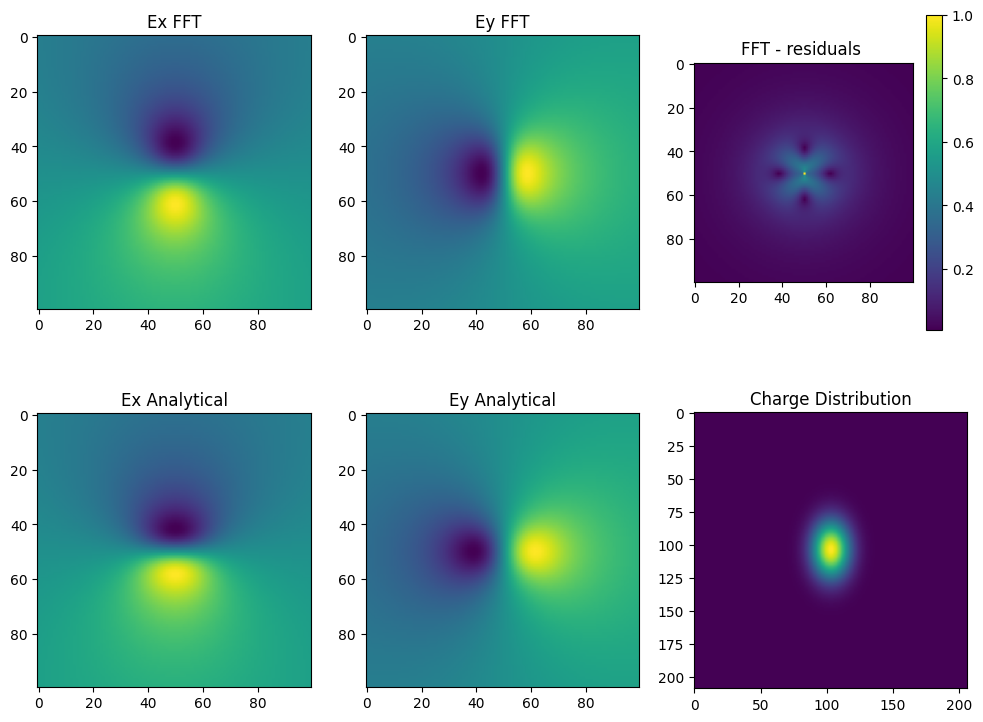

In [18]:
#print(np.shape(field_mag_fd_mesh))

fig,axs = plt.subplots(2,3, figsize=(12, 9))

axs[0][0].imshow(field_x_fft_mesh)
axs[0][0].set_title('Ex FFT')
axs[0][1].imshow(field_y_fft_mesh)
axs[0][1].set_title('Ey FFT')
im3 = axs[0][2].imshow(relative_error_fft)
axs[0][2].set_title('FFT - residuals ')
fig.colorbar(im3, ax=axs[0][2])

axs[1][0].imshow(field_x_be_mesh)
axs[1][0].set_title('Ex Analytical')
axs[1][1].imshow(field_y_be_mesh)
axs[1][1].set_title('Ey Analytical')
axs[1][2].imshow(rho_matrix)
axs[1][2].set_title('Charge Distribution')
plt.show()

## $R^2$

In [17]:
from sklearn.metrics import r2_score

r2_fft_x = r2_score(field_x_be_mesh.flatten(), field_x_fft_mesh.flatten())
r2_fft_y = r2_score(field_y_be_mesh.flatten(), field_y_fft_mesh.flatten())
r2_fft = np.mean((r2_fft_x, r2_fft_y))

print(f'R2 FFT:   {r2_fft}')

R2 FFT:   0.97807678381376
